# Deep Hedging

___
**Reference paper:**
- Deep Hedging - Buehler and al. 2018 
    https://arxiv.org/abs/1802.03042
- Equal risk pricing of financial derivative with deep hedging - Carbonneau, Godin. 2020
- Deep Learning - Goodfellow et al. 2016

**Reference code:**
- Equal risk pricing with deep hedging - Carbonneau
    https://github.com/alexandrecarbonneau/Equal-risk-pricing-with-deep-hedging/blob/master/Example%20of%20ERP%20with%20deep%20hedging.ipynb
- Deep Hedging
    https://nbviewer.org/urls/people.math.ethz.ch/~jteichma/lecture_ml_web/lecture_3.ipynb
- Option hedging with a Long-Short-Term-Memory Recurrent Neural Network mgroncki
    https://github.com/mgroncki/DataScienceNotebooks/blob/master/DeepHedging/DeepHedging_Part1.ipynb
- Deep hedging with options: https://github.com/cpmendoza 


___
# Objective

Implement a simple deep hedging framework to hedge an European call option on the underlying Black-Scholes model.

___
# 0. Packages

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm

___
# 1. Hedging Problem

Let $S_t$ be the underlying stock. You are short a European call option. At each rebalancing step $t$, you hold $\delta_t$ shares of the underlying. The P&L of the hedged portfolio is:

$$\text{PnL} = \text{Option Premium} - \text{Payoff}(S_T) + \sum_{t=0}^{T-1} \delta_t (S_{t+1} - S_t) - \text{Transaction Cost}$$

The goal is to learn $\delta_t = f_\theta(\text{state}_t)$ that minimizes a risk measure (e.g., CVaR) of the terminal P&L.

___
# 2. Black-Scholes Model

Recall in the Black-Scholes framework, the asset price $S_t$ is a Geometric Brownian Motion (GBM):

$$
dS_t = r \, S_t \, dt + \sigma \, S_t \, dW_t
$$
where $r$ is the risk free rate, $\sigma$ is the volatility (constant), and $W_t$ is a standard Brownian motion with respect to the risk neutral measure $Q$.


Given $\mathcal{F}_s$ , $s \leq t$, we obtain, using Ito's (with $\ln{x}$),
$$
S_t = S_s \, e^{(r - \frac{\sigma^2}{2}) \, (t-s) \ + \ \sigma  \, (W_t - W_s)}
$$
Equivalent to 
$$
S_t = S_s \, e^{(r - \frac{\sigma^2}{2}) \, (t-s) \ + \ \sigma \, \sqrt{t-s} \, Z_t}
$$
where $Z_t \sim \mathcal{N}(0,1)$

### (a) Simulate BS paths

In [2]:
def BS_paths(S0, r, sigma, T, N_steps, M_paths, seed = 123):
    """
    This function simulate (M_paths) Black-Scholes paths from 0 to maturity T,
    with number of discretization (N_steps)
    return shape is (N_steps + 1, M_paths + 1), 
    e.g. first column is each column is a simulation
    """
    np.random.seed(seed)
    dt = T / N_steps
    Z = np.random.randn(M_paths, N_steps)
    log_return = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.log(S0) + np.cumsum(log_return, axis=1)
    S = np.exp(log_S)
    S = np.column_stack([np.full(M_paths, S0), S])
    t = np.linspace(0, T, N_steps + 1)

    return S.astype(np.float32), t


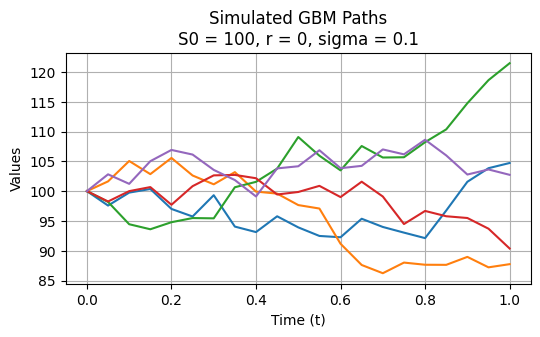

In [3]:
r = 0
sigma = 0.1
S0 = 100
S, t = BS_paths(S0 = S0, r = r, sigma = sigma, T = 1, N_steps = 20, M_paths = 5)

plt.figure(figsize=(6, 3)) 
plt.plot(t, np.transpose(S), label='S_t')

plt.title(f'Simulated GBM Paths\nS0 = {S0}, r = {r}, sigma = {sigma}')    
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.grid()
plt.show()

### (b) Black-Scholes Delta Hedging Framework

The Black-Scholes European call price is:
$$
C(S, t) = S\, \Phi(d_1) - K e^{-r(T-t)} \Phi(d_2)
$$

where $\Phi(\cdot)$ is the standard normal CDF and:
$$
d_1 = \frac{\ln(S/K) + \left(r + \frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}}, \qquad d_2 = d_1 - \sigma\sqrt{T-t}
$$

Taking the first partial derivative with respect to the asset price $S$ (called *delta*)
$$
\delta = \frac{\partial C}{\partial S} = \Phi(d_1)
$$
with $\delta \in [0,1]$ (by cdf of normal)


In the Black-Scholes delta hedging framework, the rebalancing rule is (derived by the replication portfolio):

Continuously hold $\delta_t$ shares of the underlying $S_t$ for all $t \in [0,T]$

Assuming we don't trade continuously, the discrete rule is at each time step $t$, hold $\delta_t$ shares of the underlying $S_t$ (Note that discrete hedging is not a perfect replication):

$$\delta_t = \Phi(d_1(S_t, t))$$

The hedge P&L accumulated over one step is:

$$\text{PnL}_t = \delta_{t-1} \cdot (S_t - S_{t-1})$$

and the total hedged portfolio value at maturity is:

$$\text{PnL}_{\text{total}} = \text{Call Premium} + \sum_{t=1}^{T} \text{PnL}_t - \text{Payoff}$$

##### Option pricing with Black Scholes

In [4]:
class BlackScholes:
    def __init__(self, S, K, r, sigma, T):
        self.S = S   # current asset price
        self.K = K   # strike
        self.r = r   # risk free rate
        self.sigma = sigma   #volatility
        self.T = T   # time to maturity

    def call_price(self):  
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*(self.sigma**2))*self.T)/(self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma*np.sqrt(self.T)
        return self.S*norm.cdf(d1) - self.K*np.exp(-self.r*self.T)*norm.cdf(d2)
    def put_price(self):  # by put call parity
        return self.call_price() - self.S + self.K*np.exp(-self.r * self.T)
    
    def call_delta(self):  # first derivative with respect to price S 
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*(self.sigma**2))*self.T)/(self.sigma * np.sqrt(self.T))
        return norm.cdf(d1)
    def put_delta(self):   # by derivative of put-call parity with respect to S
        return self.call_delta() - 1

##### Delta Hedging with Black Scholes

In [5]:
def delta_hedging(S, K, r, sigma, T, Initial_portfolio=0):
    """
    S: grid of simulated stock price: shape (M_paths, N_steps + 1)
    K: strike price
    r: risk free rate
    sigma: volatility
    T: time to maturity
    Initial_portfolio: initial value of the hedging portfolio (default is 0)
    return: pnl of the delta hedging strategy at maturity for each path
    """
    # parameters
    ttm = np.linspace(T, 0,S.shape[1])
    dt = T/(S.shape[1] - 1)

    # call price value (initial value of the hedging portfolio)
    call_price_maturity = np.full(S.shape[0], Initial_portfolio) * np.exp(r * T)

    # payoff (at maturity)
    payoff = np.maximum(S[:,-1] - K, 0)

    # delta (not at maturity)
    S_grid = S[:,:-1]
    T_grid = ttm[:-1]
    
    d1 = (np.log(S_grid/K) + (r + 0.5*(sigma**2))*T_grid)/(sigma * np.sqrt(T_grid))
    deltas = norm.cdf(d1)

    # pnl at each step t = 1 to T-1 

    compound = np.exp(r * (T - ttm[1:]))      # compounding each gain to maturity
    dS = S[:, 1:] - S[:, :-1] * np.exp(r * dt)         # discounted stock move
    hedging_pnl = np.sum(deltas * dS * compound, axis=1)

    # total pnl
    pnl = call_price_maturity + hedging_pnl - payoff

    return pnl

___
# 3. Deep Hedging

### (a) Introduction

To introduce the concept of deep hedging, let first consider a market with no friction (e.g. no transaction cost, no market impacts). Note that the following framework can be easily adjusted for market friction.

### (b) Theory

##### **Pricing Using a Convex Risk Measure**

Let $X_1, X_2 \in \mathcal{X}$ be the set of liabilities ($-X$ is the an asset).

Let $\rho : \mathcal{X} \rightarrow \R$ be a risk measure. $\rho$ is a convex risk measure if:
- Monotone decreasing: $X_1 \leq X_2 \Rightarrow \rho(X_1) \leq \rho(X_2)$ \
    *Smaller liability implies smaller risk*
- Translation Invariance *(Cash Invariance)*: $\rho(X+c) = \rho(X) + c$ \
    *Adding cash does not reduce risk (e.g. The hedger is indifferent between an empty portfolio and a portfolio with liability $X$ and cash $\small \rho(X)$: $\small \rho(X-\rho(X)) = \rho(X) - \rho(X) = 0$*
- Convex: $\rho(\alpha X_1 + (1-\alpha)X_2) \leq \alpha \rho (X_1) + (1-\alpha)\rho(X_2)$ \
    *Joint risk is smaller or equal to sum of individual risk (e.g. diversification can only be beneficial in term of risk)*

We will define the optimal hedging strategy as a minimizer of $\rho(X)$, where usually, depending of the measure, $X$ is the total P&L of the hedging strategy or $X$ is the losses (-P&L)

##### **Approximation Theory of a Neural Network**

Let $L, N_0, N_1, \ldots, N_L \in \mathbb{N}$, $\sigma : \mathbb{R} \to \mathbb{R}$ and for any $\ell = 1, \ldots, L$, let $W_\ell : \mathbb{R}^{N_{\ell-1}} \to \mathbb{R}^{N_\ell}$ be an affine function. A function $F : \mathbb{R}^{N_0} \to \mathbb{R}^{N_L}$ defined as

$$F(x) = W_L \circ F_{L-1} \circ \cdots \circ F_1 \quad \text{with} \quad F_\ell = \sigma \circ W_\ell \quad \text{for } \ell = 1, \ldots, L-1$$

is called a *(feed forward) neural network*. The activation function $\sigma$ is applied componentwise. $L$ denotes the number of layers, $N_1, \ldots, N_{L-1}$ denote the dimensions of the hidden layers and $N_0$, $N_L$ of the input and output layers, respectively.

Denote by $\mathcal{NN}_{\infty,d_0,d_1}^\sigma$ the set of neural networks mapping from $\mathbb{R}^{d_0} \to \mathbb{R}^{d_1}$ and with activation function $\sigma$.

**Theorem** (Universal Approximation)
- For any finite measure $\mu$ on $(\mathbb{R}^{d_0}, \mathcal{B}(\mathbb{R}^{d_0}))$ and $1 \leq p < \infty$, the set $\mathcal{NN}_{\infty,d_0,d_1}^\sigma$ is dense in $L^p(\mathbb{R}^{d_0}, \mu)$.

- If in addition $\sigma \in C(\mathbb{R})$, then $\mathcal{NN}_{\infty,d_0,d_1}^\sigma$ is dense in $C(\mathbb{R}^{d_0})$ for the topology of uniform convergence on compact sets.
    
    *(Basically, the theorem says that a Neural Network with a single hidden layer and enough neurons can approximate any function in $L^p$. This theorem is a proof of existence)*








### (c) Deep Hedging Implementation

##### Set Up Risk Measure

Consider the Conditional Value at Risk (CVaR) risk measure. CVaR is defined as $\text{CVaR}_{\alpha} = \text{E}[X \mid X \geq \text{VaR}_{\alpha}] $, where the Value at Risk at level $\alpha$ ($\text{VaR}_{\alpha}$) is the $100\alpha^\text{th}$ quantile of $X$.

The CVaR will be calculates on the losses (-P&L) as follow: $\text{CVaR}_{\alpha} = \text{VaR}_{\alpha} + \frac{1}{1-\alpha} \text{E}\left[(\text{Losses} - \text{VaR}_{\alpha})^+\right]$


Another risk measure of interest is the MSE. MSE is defined as followed:

$$
\text{MSE}[X] = \text{E} [ X^2 ]
$$

Note that the MSE does not satisties some of the risk measure properties.
However, the MSE is an interesting risk measure to look. Minimizing the MSE implies minimizing the deviation from its theoretical mean, and in the case of hedging, the theoretical mean is zero. MSE also puts equal weight to all samples, which is not the case with other risk measures such as CVaR.

##### Set Up Neural Network

Consider the following Neural Network:
- 2 Inputs: Asset price and Time to Maturity
- 2 Hidden Layers, 64 neurons per Layers *(arbitrary)*
- 1 output (delta)
- ReLU activation function: $\text{ReLU}(x) = \text{max}(x, 0)$
- Sigmoid output activation function: $\sigma(x) = \frac{1}{1+e^{-x}} \in [0,1]$

Basically, the function we want the Neural Network to approximate is the Black-Scholes delta $\Phi(d_1)$, since under a the Black-Scholes simulation, if you could rebalance continuously, the Black-Scholes delta hedging P&L would be zero (perfect hedge).

##### Create Deep Hedging Class

In [6]:
class DeepHedging(nn.Module):
    """
    Feed forward neural network with 2 hidden layers and 64 neurons each,
    - 2 inputs: (delta_{t-1}, S_t) e.g. last position, stock price
    - Activation function: ReLU
    - Output activation function: Sigmoid (ensure delta in [0,1])
    """
    def __init__(self, num_features=2, hidden_size=64):
        super().__init__()
        self.num_features = num_features
        self.hidden_size = hidden_size
        self.net = nn.Sequential(
            nn.Linear(num_features, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, 1), nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)

##### P&L function *(Intermediary Output)*

In [7]:
def calc_pnl(S, deltas, K, r, T, dt, Initial_portfolio):
    """
    Calculates the PnL of the hedging strategy.
    The PnL function is the same as the Black-Scholes delta hedging.
    Only difference is that deltas are not BlackScholes but NN optimized

    S : (N_paths, N_steps + 1)
    deltas : (N_paths, N_steps)
    K : strike price, r : risk-free rate, T : time to maturity, dt : time step
    Initial_portfolio : initial value of the hedging portfolio
    """
    # hedging steps pnl
    ttm = torch.linspace(T, 0, S.shape[1])  #(N_steps + 1,)
    compound = torch.exp(r * (T - ttm[1:]))    #(N_steps,)  
    dS = S[:, 1:] - S[:, :-1] * torch.exp(torch.tensor(r * dt))  #(N_paths, N_steps)        
    hedging_pnl = torch.sum(deltas * dS * compound, axis=1)  #(N_paths,)

    # Maturity value of the initial portfolio
    initial_value_maturity = Initial_portfolio * torch.exp(torch.tensor(r * T)) #(N_paths,)
    
    # Payoff at maturity
    payoff = torch.relu(S[:,-1] - K)    #(N_paths,)

    # total pnl
    pnl = initial_value_maturity + hedging_pnl - payoff   #(N_paths,)

    return pnl   #(N_paths,)

##### Risk Measures

In [8]:
def var_loss(pnl, alpha=0.95):
    """
    Value at Risk (VaR) loss function.
    """
    losses = -pnl  # losses are negative pnl
    var = torch.quantile(losses, alpha).detach()   # VaR estimate
    return var  # to minimize

def cvar_loss(pnl, alpha=0.95):
    """
    Conditional Value at Risk (CVaR) loss function.
    """
    losses = -pnl  # losses are negative pnl
    var = torch.quantile(losses, alpha).detach()   # VaR estimate
    cvar = var + (1 / (1 - alpha)) * torch.mean(torch.relu(losses - var))  #CVaR formula (omit negative losses)
    return cvar  # to minimize

def variance_loss(pnl):
    """
    Variance loss function.
    """
    return torch.var(pnl)  # to minimize

def mse_loss(pnl):
    """
    Mean squared error loss function with fixed mean of zero.
    This is equivalent to the second moment of the pnl distribution.
    """
    return torch.mean(pnl**2)   # to minimize

def smse_loss(pnl):
    """
    Semi-mean squared error loss function with fixed mean of zero.
    Only account for pnl values smaller than zero (losses).
    This is equivalent to the second moment of the positive pnl distribution.
    """
    loss = - pnl[pnl < 0]
    return torch.mean(loss**2)   # to minimize


##### Training Loops

In [9]:
def train_deep_hedger(S, K, r, T, Initial_portfolio, risk='cvar', alpha=0.95,
                      hidden_size=64, lr=1e-3, n_epochs=500):
    """
    Train deep hedging NN given simulated paths
    """
    # parameters
    N_paths, N_steps_plus_1 = S.shape
    N_steps = N_steps_plus_1 - 1
    dt = T / N_steps

    # Convert paths to torch tensor
    paths = torch.tensor(S, dtype=torch.float32)  #(N_paths, N_steps + 1)
    
    # 2 Features : log-moneyness and time to maturity
    log_moneyness = torch.log(paths[:, :-1] / K)  #(N_paths, N_steps)
    ttm = torch.linspace(T, 0, N_steps + 1)[1:]  #(N_steps,)
    ttm_grid = ttm.unsqueeze(0).expand(N_paths, -1)  #(N_paths, N_steps)
    features = torch.stack([log_moneyness, ttm_grid], dim=2)       # (n_paths, n_steps, 2)

    # Model
    model = DeepHedging(num_features=2, hidden_size=hidden_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(f"\nTraining Deep Hedger with {risk} loss, alpha={alpha}, hidden_size={hidden_size}, lr={lr}, n_epochs={n_epochs}")
    for epoch in range(n_epochs + 1):
        optimizer.zero_grad()

        # forward pass: get delta at every path and step simultaneously
        deltas = model(features.view(-1, 2)).view(N_paths, N_steps)  # (N_paths, N_steps)

        pnl  = calc_pnl(paths, deltas, K, r, T, dt, Initial_portfolio)  #(N_paths,)

        if risk == 'cvar':
            loss = cvar_loss(pnl, alpha)
        elif risk == 'variance':
            loss = variance_loss(pnl)
        elif risk == 'mse':
            loss = mse_loss(pnl)
        else:
            raise ValueError(f"Unknown risk measure: {risk}")

        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | loss = {loss.item():.4f} | mean P&L = {pnl.mean().item():.4f} | std = {pnl.std().item():.4f}")

    return model

##### Test model

In [10]:
def test_deephedging(model, S, K, r, T, Initial_portfolio, risk='cvar', alpha=0.95):
    # Generate new test paths
    S_test = torch.tensor(S, dtype=torch.float32)   # (N_paths, N_steps+1)

    # Build features (same as training)
    N_paths, N_steps_p1 = S_test.shape
    N_steps = N_steps_p1 - 1
    dt = T / N_steps
    log_moneyness = torch.log(S_test[:, :-1] / K)  #(N_paths, N_steps)
    ttm = torch.linspace(T, 0, N_steps + 1)[1:]  #(N_steps,)
    ttm_grid = ttm.unsqueeze(0).expand(N_paths, -1)  #(N_paths, N_steps)
    features_test = torch.stack([log_moneyness, ttm_grid], dim=2)

    # Run model
    model.eval()
    with torch.no_grad():
        deltas_test = model(features_test.view(-1, 2)).view(N_paths, N_steps)
        pnl_test = calc_pnl(S_test, deltas_test, K, r, T, dt, Initial_portfolio)

    if risk == 'cvar':
        print(f"\nTest results for CVaR {alpha*100:.0f}% risk measure:\
              \nloss : {cvar_loss(pnl_test, alpha=alpha).item():.4f} | mean P&L : {pnl_test.mean().item():.4f} | std : {pnl_test.std().item():.4f}")
    elif risk == 'variance':
        print(f"\nTest results for Variance risk measure:\
              \nloss : {variance_loss(pnl_test).item():.4f} | mean P&L : {pnl_test.mean().item():.4f} | std : {pnl_test.std().item():.4f}")
    elif risk == 'mse':
        print(f"\nTest results for MSE risk measure:\
              \nloss : {mse_loss(pnl_test).item():.4f} | mean P&L : {pnl_test.mean().item():.4f} | std : {pnl_test.std().item():.4f}")

### (d) Results

In [11]:
# test results

#simulate training paths (Black-Scholes)
S_train, t = BS_paths(S0 = 100, r = 0, sigma = 0.1, T = 1, N_steps = 1000, M_paths = 1000,seed=123)
Initial_portfolio_train = BlackScholes(S=100, K=100, r=0, sigma=0.1, T=1).call_price()

#simulate test paths (Black-Scholes)
S, t = BS_paths(S0 = 100, r = 0, sigma = 0.1, T = 1, N_steps = 1000, M_paths = 1000, seed=456)
Initial_portfolio = BlackScholes(S=100, K=100, r=0, sigma=0.1, T=1).call_price()
print(f"Initial portfolio value = {Initial_portfolio:.4f} (call option premium)")

#BS delta hedging P&L
delta_hedging_pnl = delta_hedging(S=S, K=100, r=0, sigma=0.1, T=1, Initial_portfolio=Initial_portfolio)
print(f"\nBlack-Scholes: mean P&L = {np.mean(delta_hedging_pnl):.4f} | std = {np.std(delta_hedging_pnl):.4f}")

#Deep hedging P&L
model = train_deep_hedger(S_train, K=100, r=0, T=1, Initial_portfolio=Initial_portfolio_train, risk='cvar', alpha=0.99)
test_model = test_deephedging(model, S, K=100, r=0, T=1, Initial_portfolio=Initial_portfolio, risk='cvar', alpha=0.99)

Initial portfolio value = 3.9878 (call option premium)

Black-Scholes: mean P&L = -0.0000 | std = 0.1092

Training Deep Hedger with cvar loss, alpha=0.99, hidden_size=64, lr=0.001, n_epochs=500
Epoch    0 | loss = 13.9109 | mean P&L = -0.0170 | std = 3.3224
Epoch  100 | loss = 9.0487 | mean P&L = 0.0162 | std = 2.8894
Epoch  200 | loss = 2.4703 | mean P&L = 0.0470 | std = 1.3608
Epoch  300 | loss = 1.4022 | mean P&L = 0.0436 | std = 0.8323
Epoch  400 | loss = 1.2362 | mean P&L = 0.0375 | std = 0.7307
Epoch  500 | loss = 1.1574 | mean P&L = 0.0362 | std = 0.6970

Test results for CVaR 99% risk measure:              
loss : 1.3045 | mean P&L : -0.0062 | std : 0.6760


### (e) Analyse Results

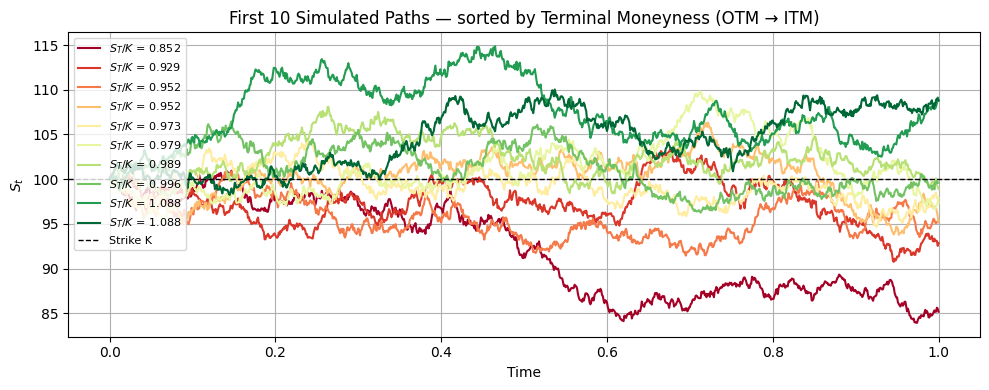

In [12]:
# --- Plot first 10 paths sorted by terminal moneyness ---
T_plot = 1
K_plot = 100
t_grid = np.linspace(0, T_plot, S.shape[1])

terminal_moneyness_all = S[:10, -1] / K_plot
sort_idx_paths = np.argsort(terminal_moneyness_all)
S_sorted = S[:10][sort_idx_paths]

cmap = plt.cm.RdYlGn
colors = [cmap(i / 9) for i in range(10)]

plt.figure(figsize=(10, 4))
for i, (path, color) in enumerate(zip(S_sorted, colors)):
    m = terminal_moneyness_all[sort_idx_paths[i]]
    plt.plot(t_grid, path, color=color, label=f'$S_T/K$ = {m:.3f}')

plt.axhline(K_plot, color='black', linestyle='--', linewidth=1, label='Strike K')
plt.title('First 10 Simulated Paths — sorted by Terminal Moneyness (OTM → ITM)')
plt.xlabel('Time')
plt.ylabel('$S_t$')
plt.legend(loc='upper left', fontsize=8)
plt.grid()
plt.tight_layout()
plt.show()


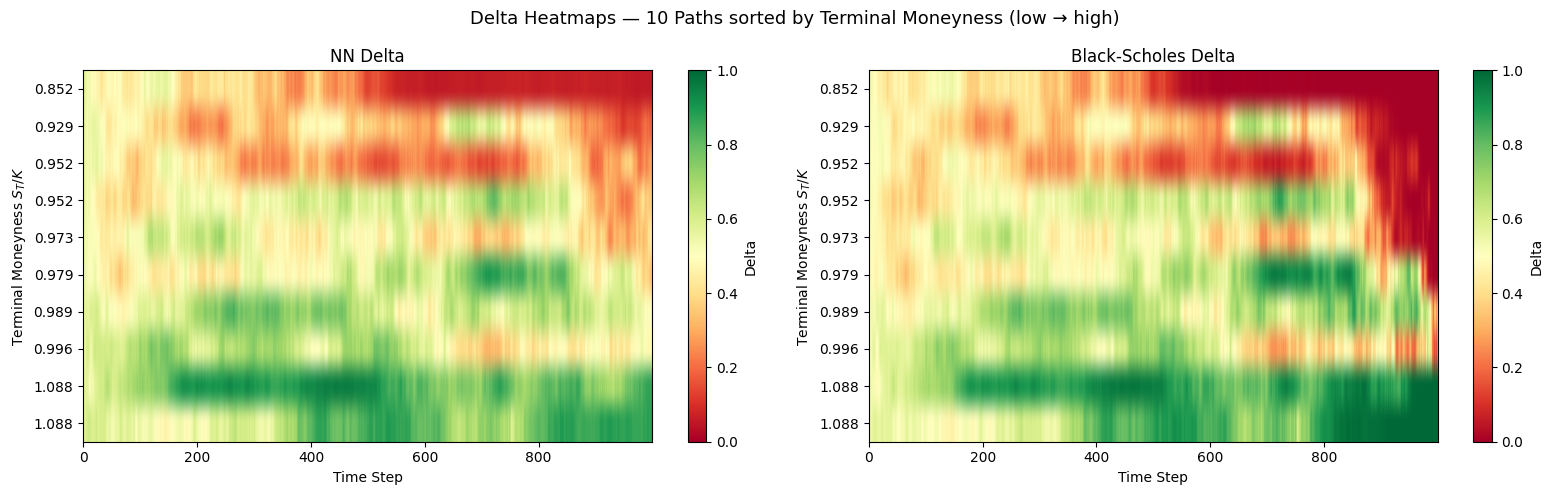

In [13]:

# --- Extract NN deltas on test paths ---
K_plot, r_plot, sigma_plot, T_plot = 100, 0, 0.1, 1

model.eval()
with torch.no_grad():
    S_test_tensor = torch.tensor(S, dtype=torch.float32)
    N_paths_plot, N_steps_p1 = S_test_tensor.shape
    N_steps_plot = N_steps_p1 - 1
    log_moneyness_plot = torch.log(S_test_tensor[:, :-1] / K_plot)
    ttm_plot = torch.linspace(T_plot, 0, N_steps_p1)[1:]
    ttm_grid_plot = ttm_plot.unsqueeze(0).expand(N_paths_plot, -1)
    features_plot = torch.stack([log_moneyness_plot, ttm_grid_plot], dim=2)
    nn_deltas = model(features_plot.view(-1, 2)).view(N_paths_plot, N_steps_plot).numpy()

# --- Extract BS deltas on test paths ---
ttm_np = np.linspace(T_plot, 0, S.shape[1])[:-1]
d1_plot = (np.log(S[:, :-1] / K_plot) + (r_plot + 0.5 * sigma_plot**2) * ttm_np) / (sigma_plot * np.sqrt(ttm_np))
bs_deltas = norm.cdf(d1_plot)

# Filter first 10 paths then sort by terminal moneyness S_T/K (low to high)
terminal_moneyness = S[:10, -1] / K_plot
sort_idx = np.argsort(terminal_moneyness)
nn_deltas_plot = nn_deltas[:10][sort_idx]
bs_deltas_plot = bs_deltas[:10][sort_idx]
ytick_labels = [f"{terminal_moneyness[i]:.3f}" for i in sort_idx]

# --- Heatmap: NN vs BS deltas ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im1 = axes[0].imshow(nn_deltas_plot, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
axes[0].set_title('NN Delta')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Terminal Moneyness $S_T/K$')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(ytick_labels)
plt.colorbar(im1, ax=axes[0], label='Delta')

im2 = axes[1].imshow(bs_deltas_plot, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
axes[1].set_title('Black-Scholes Delta')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Terminal Moneyness $S_T/K$')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(ytick_labels)
plt.colorbar(im2, ax=axes[1], label='Delta')

plt.suptitle('Delta Heatmaps — 10 Paths sorted by Terminal Moneyness (low → high)', fontsize=13)
plt.tight_layout()
plt.show()


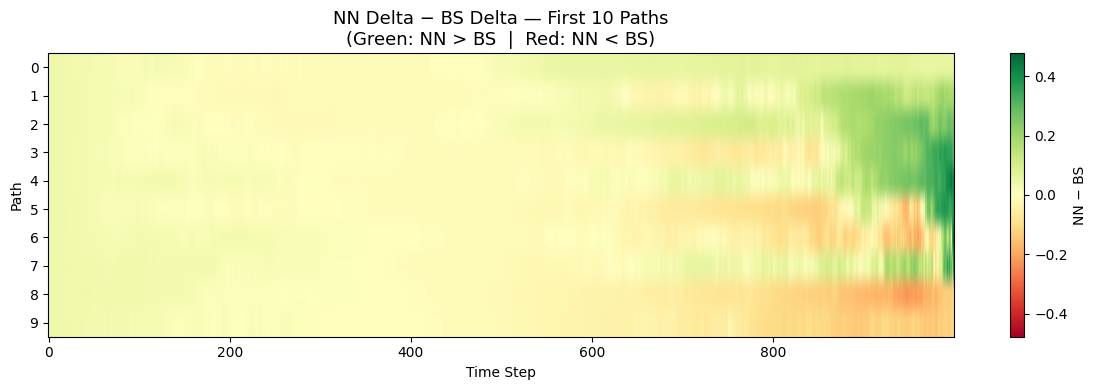

Mean difference (NN - BS): 0.0102
Std  difference (NN - BS): 0.0734


In [14]:

# --- Difference heatmap: NN - BS (first 10 paths) ---
diff = nn_deltas_plot - bs_deltas_plot
vmax = np.abs(diff).max()

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(diff, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax, origin='upper')
ax.set_title('NN Delta − BS Delta — First 10 Paths\n(Green: NN > BS  |  Red: NN < BS)', fontsize=13)
ax.set_xlabel('Time Step')
ax.set_ylabel('Path')
ax.set_yticks(range(10))
plt.colorbar(im, ax=ax, label='NN − BS')
plt.tight_layout()
plt.show()

print(f"Mean difference (NN - BS): {diff.mean():.4f}")
print(f"Std  difference (NN - BS): {diff.std():.4f}")
